# Вариант №21
Найти точку минимума функции
$$
f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75, \\
[x_1 = 0, x_2 = −3].
$$
методом Ньютона.
В окрестности точки минимума построить линии уровня и траекторию поиска (на одном графике). За своевременное выполнение задания начисляется 6 баллов.

Реализовав дополнительно следующие методы можно получить по 3 балла за каждый метод: 
- метод случайного поиска 
- метод Нелдера-Мида 
- метод Пауэлла 
- метод Хука-Дживса
- метод Розенброка

Для того, чтобы лабораторная работа была засчитана требуется оформление отчета (с формулами) с описанием используемых методов в формате Jupyter+Markdown+LaTeX.

In [28]:
import matplotlib.pyplot as plt
import numpy as np

In [29]:
# def f(x1, x2):
#     return x1**2 + 4 * x1 + 3 * x2**2 - 39 * x2 + 129.75
def f(xy):
    return xy[0]**2 + 4 * xy[0] + 3 * xy[1]**2 - 39 * xy[1] + 129.75

In [30]:
x = np.linspace(-100, 100, 1000)
y = x
x, y = np.meshgrid(x,y)
z = x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75

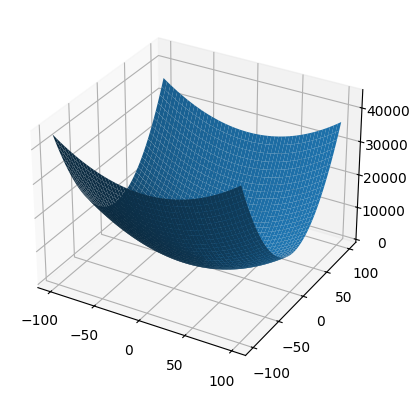

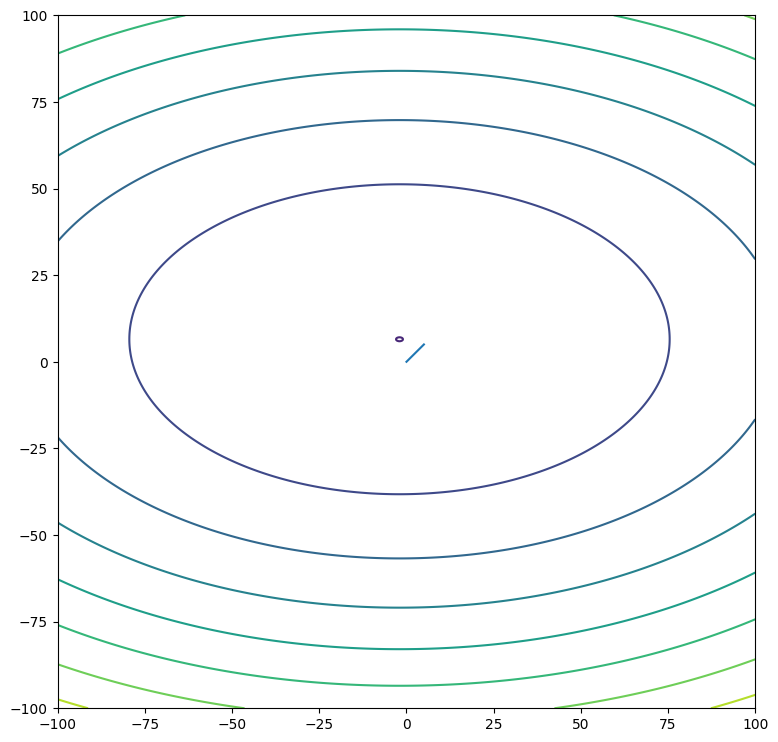

In [44]:
fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')
figu.plot_surface(x, y, z, label='sin')
# f.set(zlim=(0, 10))
# figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0,5], [0, 5])



In [32]:
Y_MIN_BOUND = -100
Y_MAX_BOUND = 100
X_MIN_BOUND = -100
X_MAX_BOUND = 100

# Метод случайного поиска
Идея: Генерируем $N$ точек в области определения функции и находим значение функции в этих точках, находим точку в которой функция принемает минимальное значение(назовём её "лучшая"), будем считать её минимумом функции.

In [40]:
def randomSearch(N):
    best = (X_MIN_BOUND, Y_MIN_BOUND)
    best_val = f(best)
    dots = []
    for _ in range(N):
        x = np.random.uniform(X_MIN_BOUND, X_MAX_BOUND)
        y = np.random.uniform(Y_MIN_BOUND, Y_MAX_BOUND)
        val = f((x, y))
        if val < best_val:
            best_val = val
            best = (x, y)
        dots.append((x, y))
    return best, dots

Результат работы Метода случайного поиска:
Полученная точка: 
x = 3.524914452015821
y = 11.79804817266374
f_min = 113.73262302169013


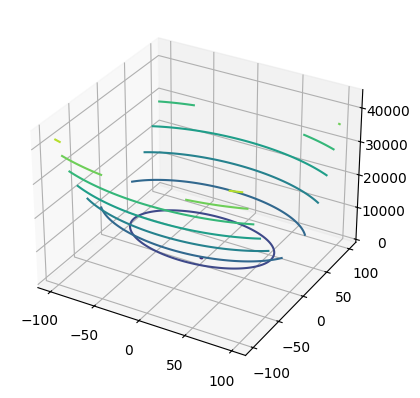

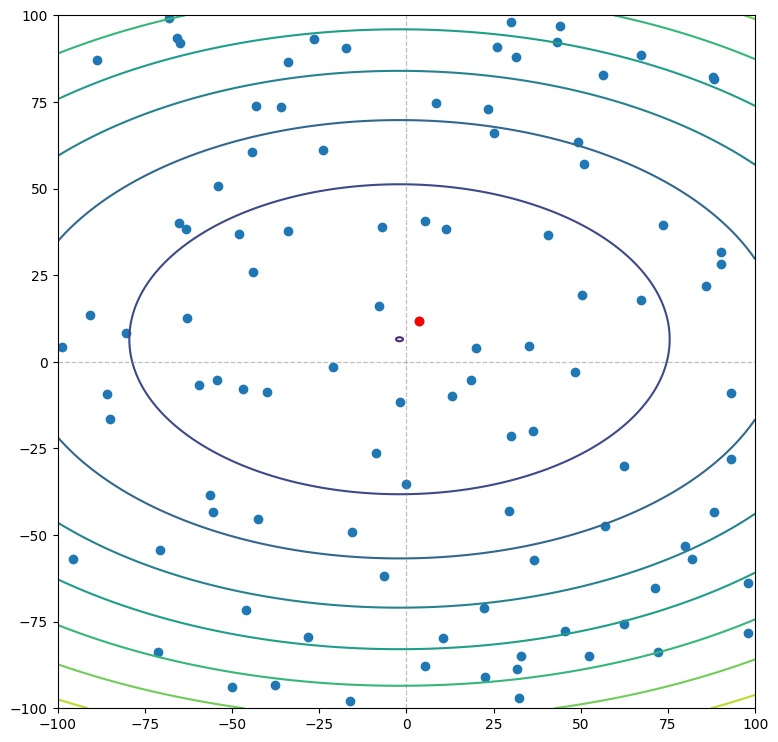

In [42]:
N = 100
res, dots = randomSearch(N)

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

# f.set(zlim=(0, 10))
figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

X_dots = [dot[0] for dot in dots]
Y_dots = [dot[1] for dot in dots]
plt.scatter(X_dots, Y_dots)
plt.scatter(res[0], res[1], color='red')


print('Результат работы Метода случайного поиска:')
print(f'Полученная точка: \nx = {res[0]}\ny = {res[1]}\nf_min = {f(res)}')